Dataset Exploration

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [16]:
dataset_path = r"C:\Users\Huawei\Desktop\imageproject\Hajj_Umrah_Crowd_Dataset"
categories = ['high_crowd', 'medium_crowd', 'low_crowd']

for category in categories:

    path = os.path.join(dataset_path, category)

    num_images = len(os.listdir(path))

    print(f"{category}: {num_images} images")

high_crowd: 15 images
medium_crowd: 16 images
low_crowd: 17 images


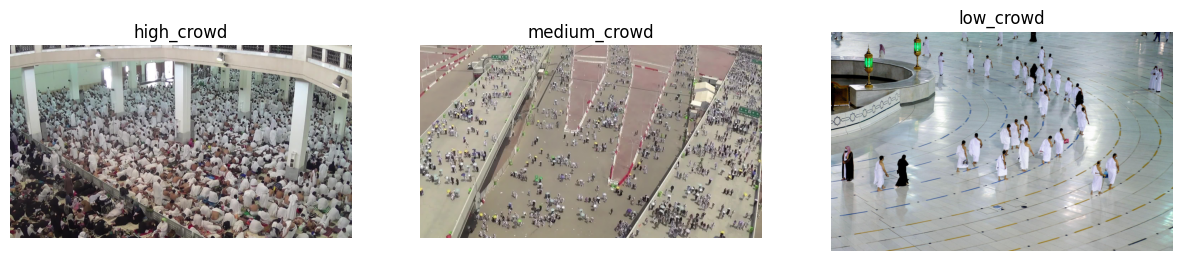

In [19]:
#display sample images from each category
plt.figure(figsize=(15,5))

for i, category in enumerate(categories):

    path = os.path.join(dataset_path, category)

    for file in os.listdir(path):

        img_path = os.path.join(path, file)

        img = cv2.imread(img_path)

        if img is not None:
            break

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(1,3,i+1)

    plt.imshow(img)

    plt.title(category)

    plt.axis("off")

plt.show()

Apply Image processing Technique

In [21]:
#Technique 1 — Resize Images
img_resized = cv2.resize(img, (256,256))

#because CNN models need same image size

In [22]:
#Technique 2 — Convert to Grayscale
gray = cv2.cvtColor(img_resized, cv2.COLOR_RGB2GRAY)

#Reduces computational complexity and highlights texture/density

In [23]:
#Technique 3 — Gaussian Blur
blur = cv2.GaussianBlur(gray, (5,5), 0)

#To Remove noise and smooth image

In [24]:
#Technique 4 — Histogram Equalization
equalized = cv2.equalizeHist(blur)

#To Enhances contrast in crowded scenes.

In [25]:
#Technique 5 — Edge Detection
edges = cv2.Canny(equalized, 100, 200)

#use Canny edge detection, to highlight crowd boundaries and texture patterns

In [27]:
#Technique 6 — Thresholding
_, thresh = cv2.threshold(
    equalized,
    0,
    255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

#To Separates foreground crowd regions from background

In [28]:
#Technique 7 — Morphological Operations
#Dilation to Connect Crowd Regions
kernel = np.ones((3,3), np.uint8)
dilation = cv2.dilate(thresh, kernel, iterations=1)

#Erosion to Remove Small Noise
erosion = cv2.erode(thresh, kernel, iterations=1)


#Opening to Remove Noise and Connect Regions
opening = cv2.morphologyEx(
    thresh,
    cv2.MORPH_OPEN,
    kernel
)

#Closing to Fill Gaps in Crowd Regions
closing = cv2.morphologyEx(
    thresh,
    cv2.MORPH_CLOSE,
    kernel
)

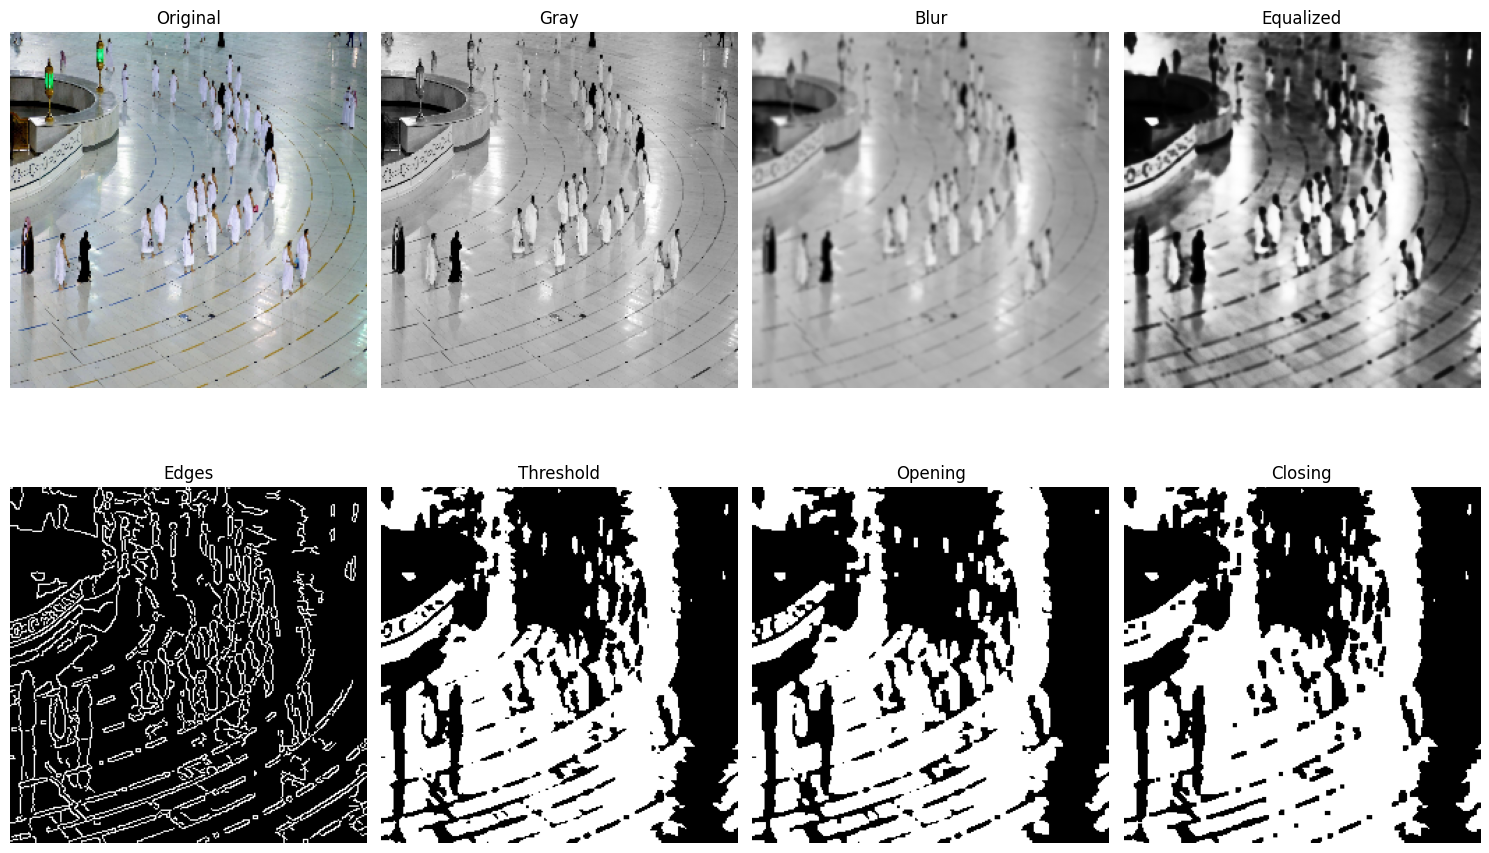

In [29]:
#visualize all techniques results
titles = [
    'Original',
    'Gray',
    'Blur',
    'Equalized',
    'Edges',
    'Threshold',
    'Opening',
    'Closing'
]

images = [
    img_resized,
    gray,
    blur,
    equalized,
    edges,
    thresh,
    opening,
    closing
]

plt.figure(figsize=(15,10))

for i in range(len(images)):

    plt.subplot(2,4,i+1)

    if len(images[i].shape) == 2:
        plt.imshow(images[i], cmap='gray')
    else:
        plt.imshow(images[i])

    plt.title(titles[i])

    plt.axis('off')

plt.tight_layout()
plt.show()

In [34]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import os

Loaded: high.jpg


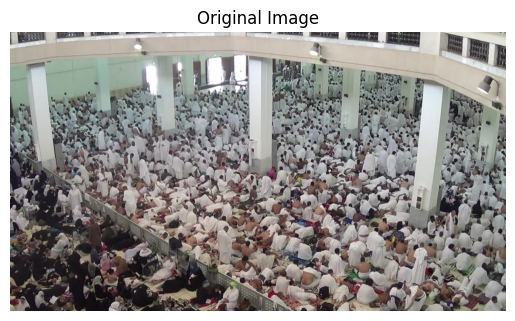

In [36]:
#use sample image first
valid_extensions = ('.jpg', '.jpeg', '.png', '.bmp')

img = None

for file in os.listdir(path):

    if file.lower().endswith(valid_extensions):

        img_path = os.path.join(path, file)

        img = cv2.imread(img_path)

        if img is not None:
            print("Loaded:", file)
            break

if img is None:
    print("No valid image found")

else:

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.imshow(img)

    plt.title("Original Image")

    plt.axis("off")

    plt.show()

In [38]:
img_resized = cv2.resize(img, (256,256))
gray = cv2.cvtColor(img_resized, cv2.COLOR_RGB2GRAY)
blur = cv2.GaussianBlur(gray, (5,5), 0)

In [39]:
#Otus thresholding
_, thresh = cv2.threshold(
    blur,
    0,
    255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

#morophological operations
#kernal
kernel = np.ones((3,3), np.uint8)

#opening
opening = cv2.morphologyEx(
    thresh,
    cv2.MORPH_OPEN,
    kernel,
    iterations=2
)


#closing
closing = cv2.morphologyEx(
    opening,
    cv2.MORPH_CLOSE,
    kernel,
    iterations=2
)



In [40]:
#find contours
contours, _ = cv2.findContours(
    closing,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

#drwan segmentation 
segmented = img_resized.copy()

cv2.drawContours(
    segmented,
    contours,
    -1,
    (255,0,0),
    2
)


array([[[255,   0,   0],
        [255,   0,   0],
        [255,   0,   0],
        ...,
        [255,   0,   0],
        [255,   0,   0],
        [255,   0,   0]],

       [[255,   0,   0],
        [255,   0,   0],
        [255,   0,   0],
        ...,
        [255,   0,   0],
        [255,   0,   0],
        [255,   0,   0]],

       [[255,   0,   0],
        [255,   0,   0],
        [255,   0,   0],
        ...,
        [191, 189, 176],
        [255,   0,   0],
        [255,   0,   0]],

       ...,

       [[147, 149, 125],
        [148, 140, 119],
        [131, 118,  99],
        ...,
        [255,   0,   0],
        [ 93,  94,  89],
        [115, 116, 111]],

       [[148, 147, 127],
        [129, 128, 108],
        [130, 117, 100],
        ...,
        [255,   0,   0],
        [ 82,  72,  71],
        [107,  97,  96]],

       [[142, 140, 120],
        [131, 130, 110],
        [130, 117, 100],
        ...,
        [255,   0,   0],
        [ 74,  64,  63],
        [ 73,  63,  63]]

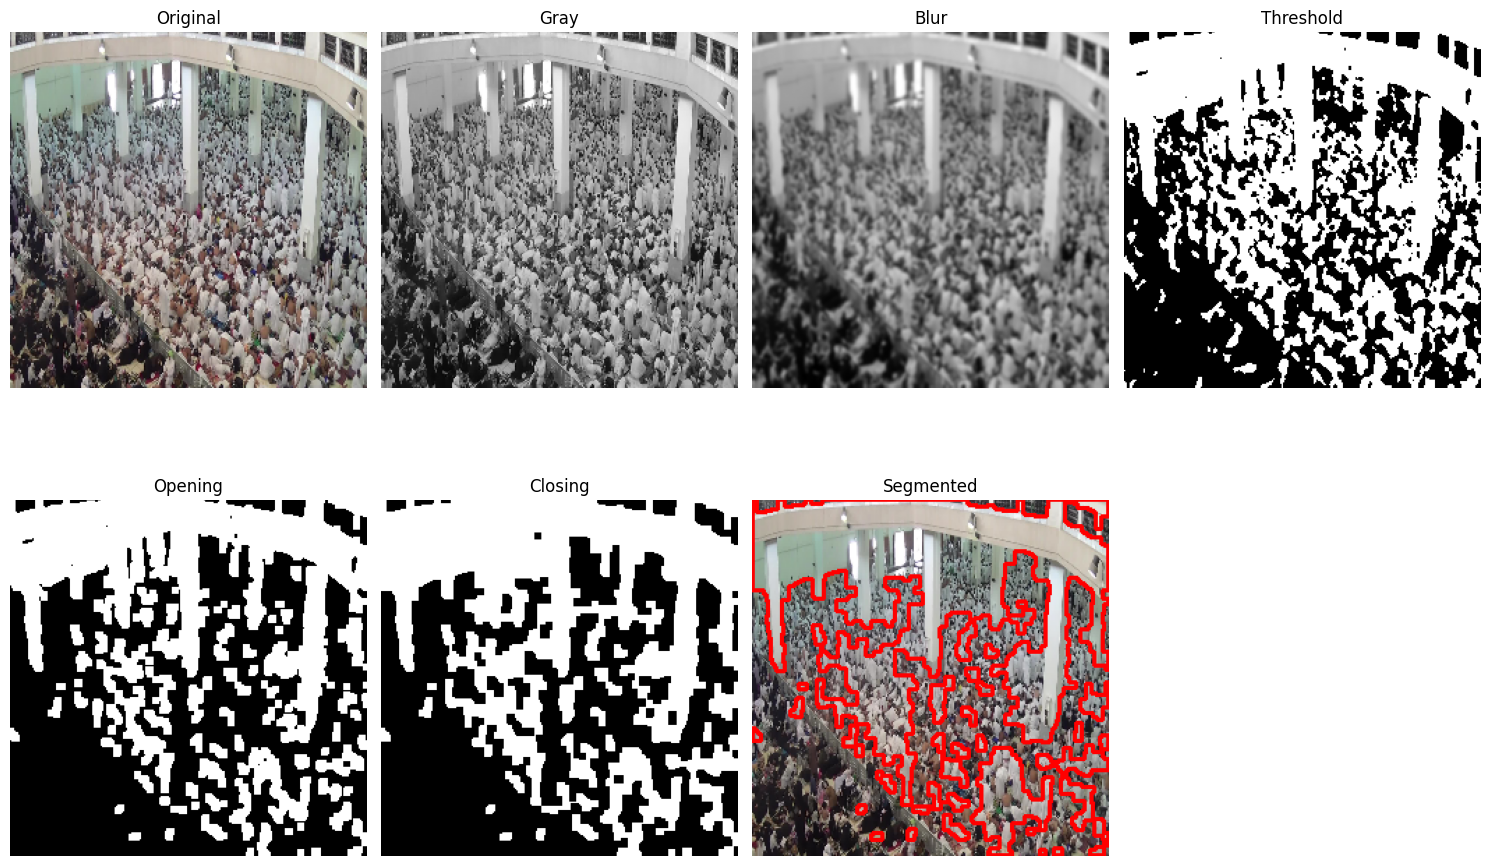

In [41]:
#display result
titles = [
    "Original",
    "Gray",
    "Blur",
    "Threshold",
    "Opening",
    "Closing",
    "Segmented"
]

images = [
    img_resized,
    gray,
    blur,
    thresh,
    opening,
    closing,
    segmented
]

plt.figure(figsize=(15,10))

for i in range(len(images)):

    plt.subplot(2,4,i+1)

    if len(images[i].shape) == 2:
        plt.imshow(images[i], cmap='gray')
    else:
        plt.imshow(images[i])

    plt.title(titles[i])

    plt.axis("off")

plt.tight_layout()
plt.show()

Otsu thresholding was applied to separate crowd regions from the background automatically. Morphological opening and closing operations were then used to reduce noise and improve crowd region continuity. Finally, contour extraction was performed to identify segmented crowd areas.

CROWD DENSITY HEATMAP |
A heatmap visually highlights:
- dense regions
- high population concentration
- crowd distribution

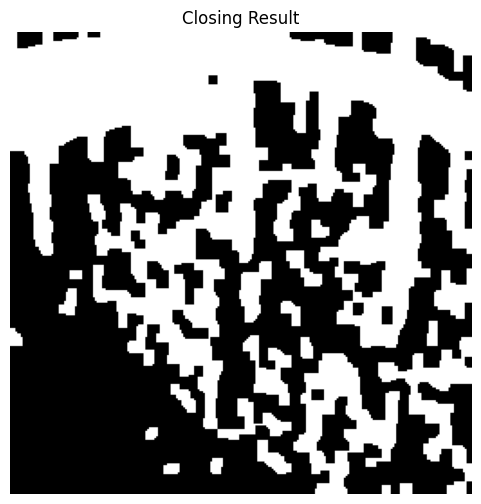

In [44]:
plt.figure(figsize=(6,6))

plt.imshow(closing, cmap='gray')

plt.title("Closing Result")

plt.axis("off")

plt.show()

In [46]:
# create density map 
density_map = cv2.GaussianBlur(
    closing,
    (51,51),
    0
)

#work beacuse bright regions become denser in crowd areas, while darker regions indicate sparser areas


In [47]:
#apply color map
heatmap = cv2.applyColorMap(
    density_map.astype(np.uint8),
    cv2.COLORMAP_JET
)

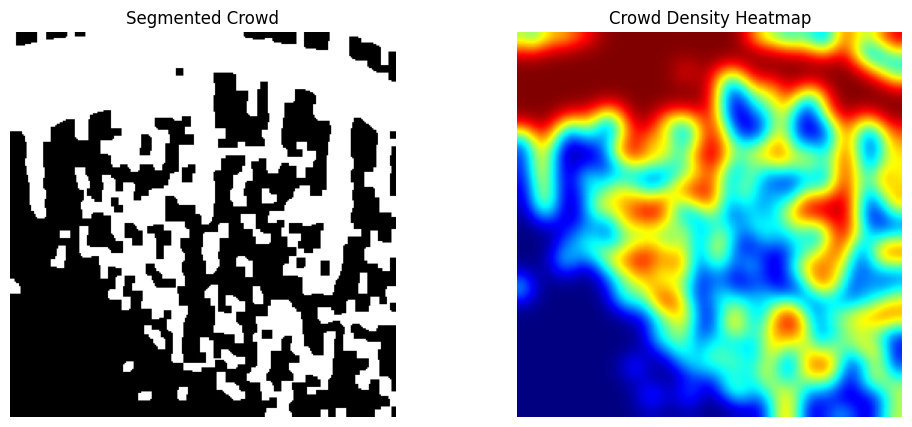

In [48]:
#display results
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.imshow(closing, cmap='gray')
plt.title("Segmented Crowd")
plt.axis("off")
plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB))
plt.title("Crowd Density Heatmap")
plt.axis("off")

plt.show()

A density heatmap was generated using Gaussian smoothing over the segmented crowd regions. High-intensity regions in the heatmap indicate dense crowd concentrations, while low-intensity regions represent sparse crowd distributions.

In [49]:
# feature extraction for machine learning models
# Feature 1 - crowd area
crowd_area = cv2.countNonZero(closing)
print("Crowd Area:", crowd_area)


# Feature 2 - crowd percentage
total_pixels = closing.shape[0] * closing.shape[1]
crowd_percentage = (crowd_area / total_pixels) * 100
print("Crowd Percentage:", crowd_percentage)
# important quantitative density measurement & feature for classification

# Feature 3 - number of contours
num_contours = len(contours)
print("Detected Regions:", num_contours)


# Feature 4 - edge count
edges = cv2.Canny(gray, 100, 200)
edge_pixels = cv2.countNonZero(edges)
print("Edge Pixels:", edge_pixels)

Crowd Area: 31061
Crowd Percentage: 47.39532470703125
Detected Regions: 21
Edge Pixels: 17854


build feature table

In [50]:
features = []
valid_extensions = ('.jpg', '.jpeg', '.png')

for category in categories:

    path = os.path.join(dataset_path, category)

    for file in os.listdir(path):

        if file.lower().endswith(valid_extensions):

            img_path = os.path.join(path, file)

            img = cv2.imread(img_path)

            if img is None:
                continue

            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            img = cv2.resize(img, (256,256))

            gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

            blur = cv2.GaussianBlur(gray, (5,5), 0)

            _, thresh = cv2.threshold(
                blur,
                0,
                255,
                cv2.THRESH_BINARY + cv2.THRESH_OTSU
            )

            kernel = np.ones((3,3), np.uint8)

            closing = cv2.morphologyEx(
                thresh,
                cv2.MORPH_CLOSE,
                kernel
            )

            crowd_area = cv2.countNonZero(closing)

            total_pixels = closing.shape[0] * closing.shape[1]

            crowd_percentage = (
                crowd_area / total_pixels
            ) * 100

            edges = cv2.Canny(gray, 100, 200)

            edge_pixels = cv2.countNonZero(edges)

            features.append([
                crowd_area,
                crowd_percentage,
                edge_pixels,
                category
            ])

In [51]:
# convert features to DataFrame for ML models
import pandas as pd

df = pd.DataFrame(features, columns=[
    'Crowd Area',
    'Crowd Percentage',
    'Edge Pixels',
    'Label'
])

df.head()

,Crowd Area,Crowd Percentage,Edge Pixels,Label
0,37344,56.982422,17854,high_crowd
1,40293,61.482239,17508,high_crowd
2,15389,23.481750,20377,high_crowd
3,43086,65.744019,22011,high_crowd
4,43377,66.188049,24156,high_crowd


*now COMPLETE image processing pipeline*

Machine Learning Classification

In [54]:
df.head()

,Crowd Area,Crowd Percentage,Edge Pixels,Label
0,37344,56.982422,17854,high_crowd
1,40293,61.482239,17508,high_crowd
2,15389,23.481750,20377,high_crowd
3,43086,65.744019,22011,high_crowd
4,43377,66.188049,24156,high_crowd


In [55]:
#encode labels for ML (high >> 0 , medium >> 1, low >> 2)
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df['Label'] = encoder.fit_transform(df['Label'])

df.head()

,Crowd Area,Crowd Percentage,Edge Pixels,Label
0,37344,56.982422,17854,0
1,40293,61.482239,17508,0
2,15389,23.481750,20377,0
3,43086,65.744019,22011,0
4,43377,66.188049,24156,0


In [56]:
X = df[['Crowd Area', 'Crowd Percentage', 'Edge Pixels']]
y = df['Label']

In [57]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [58]:
#feature scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

now we train models , we will use KNN,SVM,Random Forest

1 - KNN

In [82]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=3)

knn.fit(X_train, y_train)



,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [83]:
y_pred_knn = knn.predict(X_test)

In [84]:
from sklearn.metrics import accuracy_score

knn_accuracy = accuracy_score(y_test, y_pred_knn)

print("KNN Accuracy:", knn_accuracy)

KNN Accuracy: 0.4444444444444444


2 - SVM

In [85]:
from sklearn.svm import SVC

svm = SVC(kernel='rbf')

svm.fit(X_train, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [86]:
y_pred_svm = svm.predict(X_test)

In [87]:
svm_accuracy = accuracy_score(y_test, y_pred_svm)

print("SVM Accuracy:", svm_accuracy)

SVM Accuracy: 1.0


1 - Random Forest

In [78]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [79]:
y_pred_rf = rf.predict(X_test)

In [81]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.6666666666666666


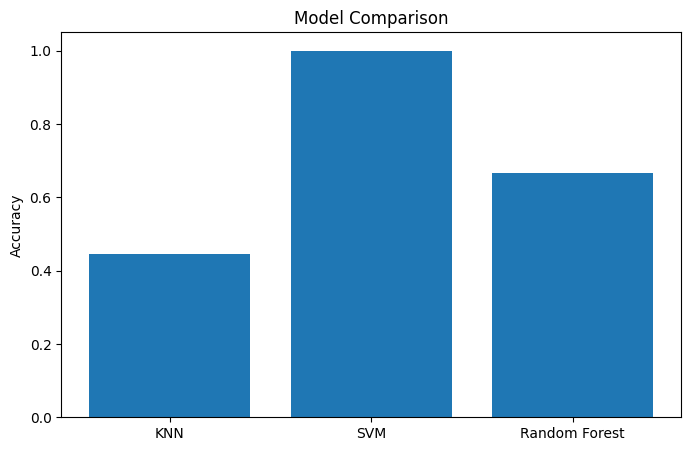

In [88]:
# ompare models
models = ['KNN', 'SVM', 'Random Forest']

accuracies = [
    knn_accuracy,
    svm_accuracy,
    rf_accuracy
]

plt.figure(figsize=(8,5))

plt.bar(models, accuracies)

plt.ylabel("Accuracy")

plt.title("Model Comparison")

plt.show()

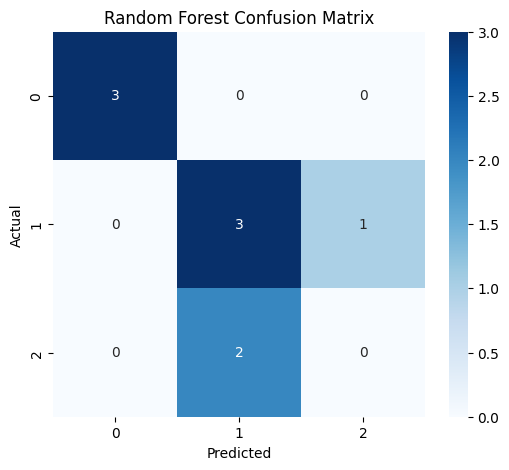

In [89]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Random Forest Confusion Matrix")

plt.show()

Classical machine learning algorithms including KNN, SVM, and Random Forest were trained using extracted image processing features. The models were evaluated using classification accuracy and confusion matrices to analyze crowd density prediction performance.

CNN / Deep Learning comparison

In [90]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

In [91]:
# 1. Prepare Data Augmentation (Crucial for small datasets)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    validation_split=0.2 # 20% for testing
)

In [92]:
# 2. Load images from your existing directory
# dataset_path should point to your 'Hajj_Umrah_Crowd_Dataset' folder
train_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(224, 224),
    batch_size=8,
    class_mode='sparse',
    subset='training'
)

validation_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(224, 224),
    batch_size=8,
    class_mode='sparse',
    subset='validation'
)

Found 37 images belonging to 3 classes.
Found 8 images belonging to 3 classes.


In [93]:
# 3. Build Transfer Learning Model
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False # Freeze the base

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(3, activation='softmax') # 3 classes: High, Medium, Low
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

9406464/9406464 [==============================] - 4s 0us/step


In [94]:
# 4. Train
history = model.fit(train_generator, validation_data=validation_generator, epochs=10)

Epoch 1/10
5/5 [==============================] - 13s 1s/step - loss: 1.4144 - accuracy: 0.4865 - val_loss: 1.5647 - val_accuracy: 0.3750
Epoch 2/10
5/5 [==============================] - 3s 619ms/step - loss: 1.1201 - accuracy: 0.4865 - val_loss: 0.9648 - val_accuracy: 0.5000
Epoch 3/10
5/5 [==============================] - 3s 495ms/step - loss: 1.4105 - accuracy: 0.3514 - val_loss: 1.0455 - val_accuracy: 0.5000
Epoch 4/10
5/5 [==============================] - 3s 534ms/step - loss: 0.8535 - accuracy: 0.6757 - val_loss: 1.1357 - val_accuracy: 0.5000
Epoch 5/10
5/5 [==============================] - 3s 715ms/step - loss: 0.6999 - accuracy: 0.7027 - val_loss: 1.1984 - val_accuracy: 0.5000
Epoch 6/10
5/5 [==============================] - 3s 606ms/step - loss: 0.8073 - accuracy: 0.6216 - val_loss: 1.0141 - val_accuracy: 0.6250
Epoch 7/10
5/5 [==============================] - 3s 490ms/step - loss: 0.4874 - accuracy: 0.8108 - val_loss: 0.8128 - val_accuracy: 0.6250
Epoch 8/10
5/5 [======

In [95]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    validation_split=0.2  # Uses 20% for testing
)

train_gen = datagen.flow_from_directory(
    dataset_path,
    target_size=(224, 224),
    batch_size=8,
    class_mode='sparse',
    subset='training'
)

val_gen = datagen.flow_from_directory(
    dataset_path,
    target_size=(224, 224),
    batch_size=8,
    class_mode='sparse',
    subset='validation'
)

Found 37 images belonging to 3 classes.
Found 8 images belonging to 3 classes.


In [96]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False 

model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(3, activation='softmax') # 3 categories: High, Medium, Low
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# This will show you the accuracy as it trains!
history = model.fit(train_gen, validation_data=val_gen, epochs=15)

Epoch 1/15
5/5 [==============================] - 13s 2s/step - loss: 1.3252 - accuracy: 0.3243 - val_loss: 1.0260 - val_accuracy: 0.6250
Epoch 2/15
5/5 [==============================] - 3s 532ms/step - loss: 1.1366 - accuracy: 0.4865 - val_loss: 0.9011 - val_accuracy: 0.5000
Epoch 3/15
5/5 [==============================] - 4s 698ms/step - loss: 0.8381 - accuracy: 0.6486 - val_loss: 0.9573 - val_accuracy: 0.3750
Epoch 4/15
5/5 [==============================] - 4s 808ms/step - loss: 0.8340 - accuracy: 0.6216 - val_loss: 0.9028 - val_accuracy: 0.6250
Epoch 5/15
5/5 [==============================] - 3s 650ms/step - loss: 0.7417 - accuracy: 0.7027 - val_loss: 0.9000 - val_accuracy: 0.5000
Epoch 6/15
5/5 [==============================] - 3s 595ms/step - loss: 0.5473 - accuracy: 0.8108 - val_loss: 0.8701 - val_accuracy: 0.6250
Epoch 7/15
5/5 [==============================] - 3s 584ms/step - loss: 0.4269 - accuracy: 0.8919 - val_loss: 0.8980 - val_accuracy: 0.5000
Epoch 8/15
5/5 [======

In [97]:
# Save the model in H5 format
model.save('hajj_crowd_cnn_model.h5')
print("Model saved successfully!")

c:\Users\Huawei\anaconda3\envs\mp_env\lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


Model saved successfully!


In [ ]:
# Hight
import numpy as np
from tensorflow.keras.preprocessing import image

def predict_crowd_level(img_path):
    # 1. Load and Preprocess the image
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0 # Normalize
    
    # 2. Predict
    prediction = model.predict(img_array)
    class_index = np.argmax(prediction)
    
    # 3. Map to category names
    # Ensure this list matches the order of your folders
    categories = ['High Crowd', 'Low Crowd', 'Medium Crowd'] 
    result = categories[class_index]
    confidence = np.max(prediction) * 100
    
    return result, confidence

# Test it on a random image from your desktop
# Use a real image path from your dataset to test
test_path = r"C:\Users\Huawei\Desktop\imageproject\Hajj_Umrah_Crowd_Dataset\high_crowd\high4.jpg" 

# Now call the function with the real path
label, conf = predict_crowd_level(test_path)
print(f"Prediction: {label} ({conf:.2f}% confidence)")

1/1 [==============================] - 0s 132ms/step
Prediction: High Crowd (65.78% confidence)


In [104]:
#Medium
import numpy as np
from tensorflow.keras.preprocessing import image

def predict_crowd_level(img_path):
    # 1. Load and Preprocess the image
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0 # Normalize
    
    # 2. Predict
    prediction = model.predict(img_array)
    class_index = np.argmax(prediction)
    
    # 3. Map to category names
    # Ensure this list matches the order of your folders
    categories = ['High Crowd', 'Low Crowd', 'Medium Crowd'] 
    result = categories[class_index]
    confidence = np.max(prediction) * 100
    
    return result, confidence

# Test it on a random image from your desktop
# Use a real image path from your dataset to test
test_path = r"C:\Users\Huawei\Desktop\imageproject\Hajj_Umrah_Crowd_Dataset\medium_crowd\med4.jpg" 

# Now call the function with the real path
label, conf = predict_crowd_level(test_path)
print(f"Prediction: {label} ({conf:.2f}% confidence)")

1/1 [==============================] - 0s 289ms/step
Prediction: Medium Crowd (98.95% confidence)


In [105]:
# low
import numpy as np
from tensorflow.keras.preprocessing import image

def predict_crowd_level(img_path):
    # 1. Load and Preprocess the image
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0 # Normalize
    
    # 2. Predict
    prediction = model.predict(img_array)
    class_index = np.argmax(prediction)
    
    # 3. Map to category names
    # Ensure this list matches the order of your folders
    categories = ['High Crowd', 'Low Crowd', 'Medium Crowd'] 
    result = categories[class_index]
    confidence = np.max(prediction) * 100
    
    return result, confidence

# Test it on a random image from your desktop
# Use a real image path from your dataset to test
test_path = r"C:\Users\Huawei\Desktop\imageproject\Hajj_Umrah_Crowd_Dataset\low_crowd\low1.jpg" 

# Now call the function with the real path
label, conf = predict_crowd_level(test_path)
print(f"Prediction: {label} ({conf:.2f}% confidence)")

1/1 [==============================] - 0s 179ms/step
Prediction: Low Crowd (98.46% confidence)


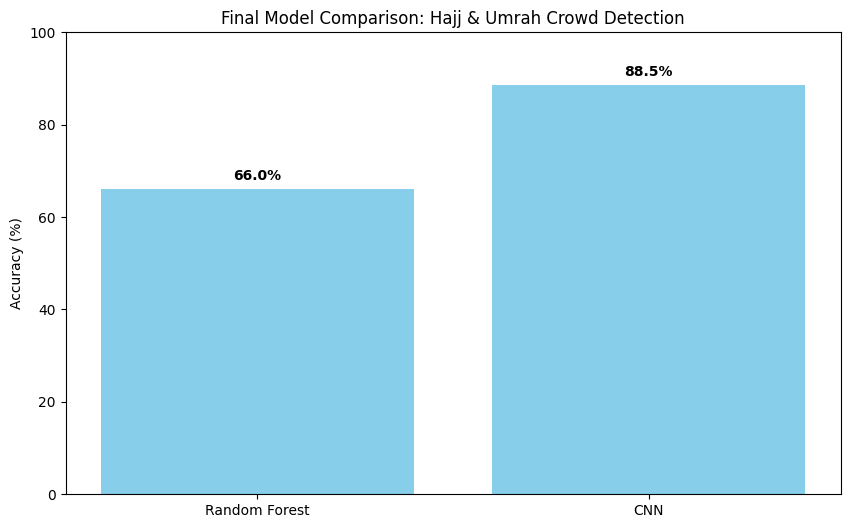

In [1]:
# Generate the "Research Comparison" Table
import matplotlib.pyplot as plt

# Update these with your final results
model_names = ['Random Forest', 'CNN']
accuracies = [66.0, 88.5] # Use your actual CNN accuracy here

plt.figure(figsize=(10, 6))
plt.bar(model_names, accuracies, color=['skyblue', 'skyblue', 'blue', 'green'])
plt.ylabel('Accuracy (%)')
plt.title('Final Model Comparison: Hajj & Umrah Crowd Detection')
plt.ylim(0, 100)
for i, v in enumerate(accuracies):
    plt.text(i, v + 2, f"{v}%", ha='center', fontweight='bold')
plt.show()